In [1]:
# Beginning taken from: 02_image_data_visualization.ipynb
import cv2
from astroquery.skyview import SkyView
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import ZScaleInterval

In [2]:
!pip install astroquery

In [3]:
# Get the Andromeda data (M31) from SDSSg Survey using SkyView
hdu = SkyView.get_images("M31", "SDSSg")[0][0]
hdu

In [4]:
# Get the pixels data from HDU
M31_Pixels = hdu.data

In [5]:
# Check the shape of the array
M31_Pixels.shape

(300, 300)

In [6]:
# A Common Function that will be used to plot the scaled pixel arrays
def plot_pixels(pixel_array, title, color):
  plt.imshow(pixel_array, cmap='gray', origin='lower')
  plt.title(title, color=color, weight='bold')
  plt.axis('off')

In [7]:
def compare_pixels(scaled_array, title):
  plt.subplot(1, 2, 1)
  plot_pixels(M31_Pixels, title='Original Image', color='black')
  plt.subplot(1, 2, 2)
  plot_pixels(scaled_array, title=title, color='royalblue')
  plt.tight_layout()
  plt.show()

In [8]:
# Log Normalization is simply the log of pixels! Create a function for the same!
def log_normalization(pixel_array):
  return np.log(pixel_array)

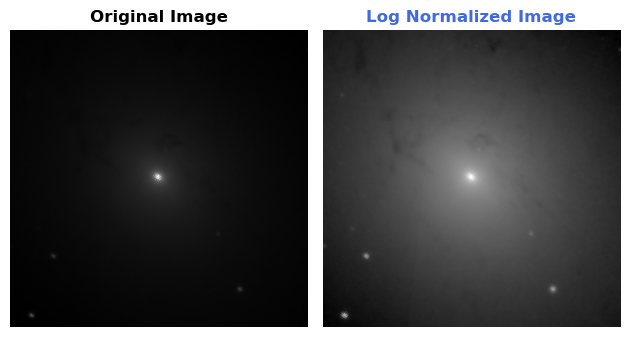

In [9]:
# Visualize the log normalization on M31 data
log_norm_array = log_normalization(M31_Pixels)
compare_pixels(log_norm_array, title='Log Normalized Image')

In [10]:
# Get the shape
log_norm_array.shape

(300, 300)

In [11]:
# Create the object for ZScaleInterval
z = ZScaleInterval()
# Get min and max values of the M31 data
z1, z2 = z.get_limits(log_norm_array)
# Check z1 and z2
print(f'Minimum = {z1}')
print(f'Maximum = {z2}')

Minimum = 1.6889997720718384
Maximum = 4.447910199027213


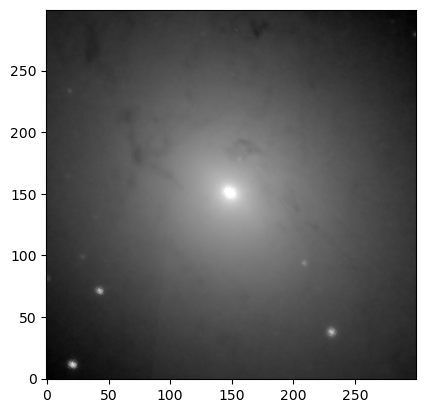

In [12]:
# Plot the M31 data using this interval
img = plt.imshow(log_norm_array, vmin=z1, vmax=z2, cmap='gray', origin='lower')
plt.show()

In [13]:
# Get the array created from the above cell
image_array = img.make_image(renderer=None, unsampled=True)[0]

In [14]:
# shape - check the channels
image_array.shape

(300, 300, 4)

In [15]:
# Convert 4 channel image to grayscale image
gray_array = cv2.cvtColor(image_array, cv2.COLOR_BGRA2GRAY)

In [16]:
# Check if channels are set to 3 or 4 now
gray_array.shape

(300, 300)

In [17]:
# Store grayscale in a new variable (will be using it later)
grayscale_zint_array = gray_array

In [18]:
print(grayscale_zint_array)

[[ 0  0  0 ... 29 30 29]
 [ 0  0  0 ... 31 29 29]
 [ 1  0  0 ... 29 31 29]
 ...
 [28 28 30 ...  1  4  5]
 [29 31 31 ...  4  4  2]
 [30 30 31 ...  1  3  2]]


## Denoising using Gaussian
It is technically Blurring the image by removing noises...Which is prerequisite to many filters and this is known as Gaussian Smoothing.many

In [19]:
# We will need convolution 2D filter from Scipy's signal module
from scipy.signal import convolve2d

In [20]:
# Generate your kernel/filter
kernel = np.ones((3,3))/9

In [21]:
# Let's see how it looks
kernel

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

In [22]:
# Create a gaussian kernel
gaussian_kernel = np.array([[1/16, 1/8, 1/16],
                            [1/8, 1/4, 1/8],
                            [1/16, 1/8, 1/16]])

In [23]:
# Get the convolution done using our kernel
convolved_image = convolve2d(M31_Pixels, kernel, mode='same')

In [24]:
# Convolution done using gaussian kernel
gaussian_convolved_image = convolve2d(M31_Pixels, gaussian_kernel, mode='same')

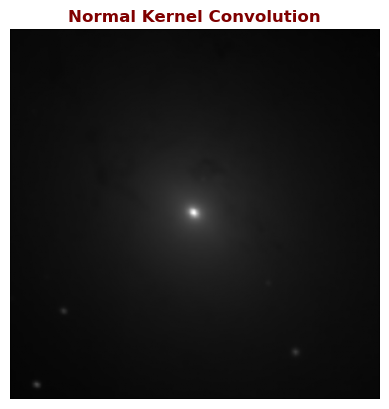

In [25]:
# Visualize the first kernel convolution
plot_pixels(convolved_image, title='Normal Kernel Convolution', color='maroon')

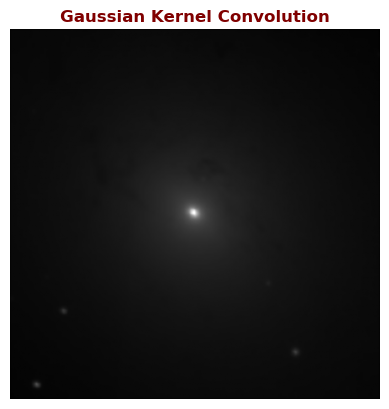

In [26]:
# Visualize the gaussian kernel convolved output
plot_pixels(gaussian_convolved_image, title='Gaussian Kernel Convolution', color='maroon')

In [27]:
# Using grayscale of M31 data to convolve with gaussian kernel
convolved_grayscale = convolve2d(grayscale_zint_array, gaussian_kernel, mode='same')

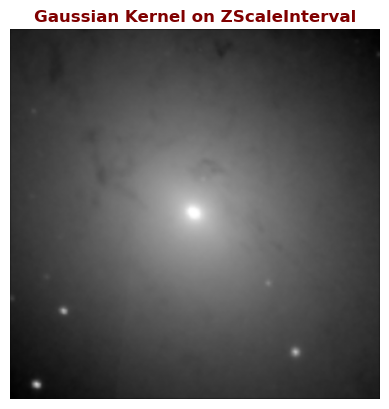

In [28]:
# Check how this looks now!
plot_pixels(convolved_grayscale, title='Gaussian Kernel on ZScaleInterval', color='maroon')

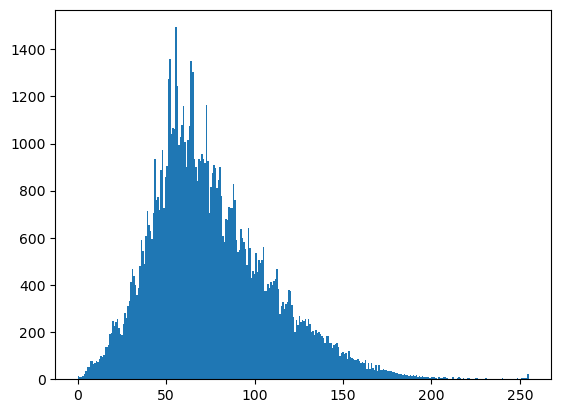

In [29]:
# Get the histogram
plt.hist(convolved_grayscale.flat, bins=300)
plt.show()

## Enhancing the Linear Features on M31
Take a look onto different available filters in skimage:-
https://scikit-image.org/docs/stable/api/skimage.filters.html